In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import scorecardpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

In [4]:
##import cleaned dataset
df = pd.read_csv("final_application_data.csv")
print("Data loaded successfully. Shape:", df.shape)

Data loaded successfully. Shape: (173647, 81)


In [3]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_11,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AGE_YEARS,EMP_YEARS,TOTAL_ENQUIRIES,BUREAU_RECORD_COUNT,BUREAU_RECENT_CREDIT,BUREAU_AVG_CREDIT_AGE,BUREAU_MEAN_OVERDUE_DAYS,BUREAU_EARLIEST_ENDDATE,BUREAU_LATEST_ENDDATE,BUREAU_LATEST_CLOSED,BUREAU_MAX_AMT_OVERDUE,BUREAU_MAX_PROLONGATIONS,BUREAU_MAX_CREDIT,BUREAU_MEAN_DEBT,BUREAU_TOTAL_LIMIT,BUREAU_TOTAL_AMT_OVERDUE,BUREAU_CREDIT_TYPE_COUNT,BUREAU_OLDEST_UPDATE,BUREAU_TOTAL_ANNUITY,BUREAU_TYPE_CREDIT_CARD,BUREAU_TYPE_MICROLOAN,BUREAU_TYPE_MORTGAGE,BUREAU_TYPE_OTHER,HAS_NO_CLOSED_CREDIT,HAS_NO_ENDDATE,BUREAU_DEBT_UTIL,BUREAU_AVG_PROLONGATIONS,BUREAU_ACTIVE_RATE,BUREAU_BAD_SOLD_RATE,LTV_RATIO,ANNUITY_INCOME_RATIO,DEBT_TO_ANNUITY,DEF_RATE_60,BUREAU_CONSUMER_CREDIT_RATE
count,173647.00,173647.00,173647.00,173646.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,137453.00,173646.00,146758.00,146758.00,146758.00,146758.00,145467.00,145467.00,127665.00,146757.00,146758.00,146757.00,146758.00,146758.00,146758.00,146758.00,146757.00,146758.00,146758.00,146758.00,146758.00,146758.00,146758.00,146758.00,104787.00,146758.00,146758.00,146758.00,173647.00,173647.00,173647.00,173647.00,146758.00
mean,278124.14,0.09,0.37,154495.06,26935.99,0.02,-5173.83,-2995.62,0.79,0.21,1.00,0.28,0.05,2.05,12.00,0.01,0.04,0.08,0.21,-956.41,0.00,0.82,0.00,0.02,0.11,0.04,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.01,0.00,0.00,0.00,44.65,6.71,2.18,5.44,-492.25,-1071.62,1.17,-993.63,4315.99,-536.75,4380.50,0.04,728552.29,126321.02,21319.43,245.41,1.66,-1157.90,17746.33,1.29,0.04,0.05,0.01,0.13,0.01,4.58,0.01,0.41,0.00,1.14,0.19,21.90,0.05,0.74
std,102748.19,0.29,0.69,80982.38,13364.64,0.01,3586.91,1502.46,0.41,0.40,0.02,0.45,0.22,0.50,3.27,0.12,0.21,0.27,0.41,820.15,0.01,0.39,0.01,0.12,0.31,0.19,0.07,0.06,0.01,0.05,0.01,0.10,0.02,0.09,0.02,0.02,0.00,11.79,6.70,2.27,4.33,545.02,568.31,27.93,2593.13,9368.53,544.43,63151.30,0.23,1340609.49,426114.67,86236.31,17787.16,0.56,828.90,340235.87,1.48,0.53,0.24,0.13,0.34,0.09,1.25,0.07,0.31,0.04,0.12,0.10,8.05,0.20,0.27
min,100002.00,0.00,0.00,25650.00,1615.50,0.00,-23738.00,-7197.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,-4173.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,21.00,0.00,0.00,1.00,-2922.00,-2922.00,0.00,-4736.00,-2858.00,-2887.00,0.00,0.00,0.00,-684441.18,0.00,0.00,1.00,-2917.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,8.04,0.00,0.00
25%,189120.00,0.00,0.00,103500.00,17374.50,0.01,-7796.00,-4291.00,1.00,0.00,1.00,0.00,0.00,2.00,10.00,0.00,0.00,0.00,0.00,-1560.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,34.80,2.10,0.00,2.00,-626.00,-1424.83,0.00,-2133.00,84.00,-730.00,0.00,0.00,157500.00,0.00,0.00,0.00,1.00,-1897.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00,0.00,0.19,0.00,1.00,0.13,15.27,0.00,0.60
50%,278191.00,0.00,0.00,135000.00,24984.00,0.02,-4677.00,-3242.00,1.00,0.00,1.00,0.00,0.00,2.00,12.00,0.00,0.00,0.00,0.00,-758.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,44.50,4.50,2.00,4.00,-297.00,-1034.00,0.00,-1270.00,852.00,-351

## Fine Classing

In [10]:
# 1. Feature Selection & Data Preparation
# Exclude identifiers and the target itself
target = 'TARGET'
feature_cols = [df_col for df_col in df.columns if df_col != target and df_col != 'SK_ID_CURR']

print("columns excluded:" + ", ".join([col for col in df.columns if col not in feature_cols]))

# Prepare data: ensure 'Missing' is treated as NaN for scorecardpy
df_processed = df[feature_cols + [target]].copy()
df_processed = df_processed.replace('Missing', np.nan)

# Ensure target is numeric 0/1
df_processed[target] = pd.to_numeric(df_processed[target], errors='coerce')
df_processed = df_processed.dropna(subset=[target])
df_processed[target] = df_processed[target].astype(int)


# 2. Target Distribution Check
goods = (df_processed[target] == 0).sum()
bads = (df_processed[target] == 1).sum()

print("\nDataset Summary:")
print(f"  - Goods: {goods:,} | Bads: {bads:,} | Bad Rate: {bads / len(df_processed):.2%}")

# 3. Perform Fine Classing (WOE Binning)
print("\n" + "=" * 50)
print("PERFORMING FINE CLASSING (Minimum 20 Bins)")
print("=" * 50)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    # IMPORTANT:
    # ignore_datetime_cols=False prevents scorecardpy from calling its internal
    # datetime checker that can fail with newer pandas versions.
    bins = sc.woebin(
        df_processed,
        y=target,
        min_num_bins=20,        # Force fine granularity
        stop_limit=0.0001,      # Smallest IV gain to keep splitting
        count_distr_limit=0.02, # Allow bins as small as 2% of total
        bin_num_limit=50,       # Max upper limit
        positive='bad|1',       # Ensure 1 is treated as the bad/default event
        ignore_datetime_cols=False,
        check_cate_num=False
    )

# 4. Extract IV Summary
# scorecardpy stores total IV for each variable within each variable's binning dataframe
iv_list = []
for var, df_bin in bins.items():
    if df_bin is not None and not df_bin.empty:
        iv_val = df_bin['total_iv'].iloc[0]
        iv_list.append({
            'Variable': var,
            'IV': iv_val,
            'Bins': len(df_bin)
        })

iv_df = pd.DataFrame(iv_list).sort_values('IV', ascending=False).reset_index(drop=True)

print("\nVariable IV Summary:")
display(iv_df.head(30))

columns excluded:SK_ID_CURR, TARGET

Dataset Summary:
  - Goods: 158,018 | Bads: 15,629 | Bad Rate: 9.00%

PERFORMING FINE CLASSING (Minimum 20 Bins)
[INFO] creating woe binning ...
Binning on 173647 rows and 80 columns in 00:02:09

Variable IV Summary:


,Variable,IV,Bins
0,DEBT_TO_ANNUITY,0.19,21
1,EMP_YEARS,0.13,22
2,BUREAU_AVG_CREDIT_AGE,0.13,22
3,AGE_YEARS,0.11,30
4,BUREAU_ACTIVE_RATE,0.10,15
5,OCCUPATION_TYPE,0.09,11
6,ORGANIZATION_TYPE,0.09,15
7,LTV_RATIO,0.08,15
8,BUREAU_RECENT_CREDIT,0.08,19
9,BUREAU_OLDEST_UPDATE,0.07,22


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 4: Extract IV values and Bin Statistics
# ─────────────────────────────────────────────────────────────────────────────

# Extract IV values for all variables using your 'bins' dictionary
iv_summary = {}
woe_details = {}

for var_name, bin_info in bins.items():
    # scorecardpy repeats the total_iv in every row of the binning dataframe
    if isinstance(bin_info, pd.DataFrame) and 'total_iv' in bin_info.columns:
        iv_value = bin_info['total_iv'].iloc[0] if not bin_info.empty else 0
    else:
        iv_value = 0
    
    iv_summary[var_name] = iv_value
    woe_details[var_name] = bin_info

# Create IV summary DataFrame
iv_df = pd.DataFrame({
    'Variable': list(iv_summary.keys()),
    'IV': list(iv_summary.values())
}).sort_values('IV', ascending=False).reset_index(drop=True)

print(f"\n✓ IV values extracted for {len(iv_summary)} variables")
print(f"\nTop 15 variables by IV:")
print("-" * 80)
print(iv_df.head(15).to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# Step 5: Bin Count Statistics
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "-" * 80)
print("BIN COUNT STATISTICS")
print("-" * 80)

bin_counts = []
for var_name, bin_info in bins.items():
    if isinstance(bin_info, pd.DataFrame):
        # In scorecardpy, each row in bin_info is a distinct bin
        num_bins = len(bin_info)
        bin_counts.append({'Variable': var_name, 'Num_Bins': num_bins})

bin_counts_df = pd.DataFrame(bin_counts).sort_values('Num_Bins', ascending=False)

# Identify variables that successfully reached your 'min_num_bins=20' target
vars_20plus = bin_counts_df[bin_counts_df['Num_Bins'] >= 20]
print(f"\nVariables with 20+ bins:")
print("-" * 80)
print(f"  Count: {len(vars_20plus)} variables")

if len(vars_20plus) > 0:
    print(f"\n  Top variables by bin count:")
    for idx, row in vars_20plus.head(10).iterrows():
        print(f"    - {row['Variable']}: {row['Num_Bins']} bins")

print(f"\n\nOverall Bin Summary:")
print(f"  - Mean bins per variable: {bin_counts_df['Num_Bins'].mean():.1f}")
print(f"  - Median bins per variable: {bin_counts_df['Num_Bins'].median():.1f}")
print(f"  - Max bins: {bin_counts_df['Num_Bins'].max()}")

# ─────────────────────────────────────────────────────────────────────────────
# Step 6: Detailed WOE for the Top Variable
# ─────────────────────────────────────────────────────────────────────────────
if not iv_df.empty:
    top_var = iv_df.iloc[0]['Variable']
    print("\n" + "=" * 80)
    print(f"WOE DETAILS FOR TOP VARIABLE: {top_var}")
    print("=" * 80)
    print(f"Total IV: {iv_df.iloc[0]['IV']:.4f}")
    
    if top_var in woe_details:
        top_var_bins = woe_details[top_var]
        # These are the standard scorecardpy columns
        display_cols = ['bin', 'count', 'count_distr', 'good', 'bad', 'badprob', 'woe', 'bin_iv']
        available_cols = [col for col in display_cols if col in top_var_bins.columns]
        
        print(f"\nDetailed Bin breakdown:")
        print("-" * 80)
        print(top_var_bins[available_cols].to_string(index=False))

print("\n" + "=" * 80)
print("FINE CLASSING COMPLETE")
print("=" * 80)


✓ IV values extracted for 79 variables

Top 15 variables by IV:
--------------------------------------------------------------------------------
               Variable   IV
        DEBT_TO_ANNUITY 0.19
              EMP_YEARS 0.13
  BUREAU_AVG_CREDIT_AGE 0.13
              AGE_YEARS 0.11
     BUREAU_ACTIVE_RATE 0.10
        OCCUPATION_TYPE 0.09
      ORGANIZATION_TYPE 0.09
              LTV_RATIO 0.08
   BUREAU_RECENT_CREDIT 0.08
   BUREAU_OLDEST_UPDATE 0.07
       NAME_INCOME_TYPE 0.07
BUREAU_EARLIEST_ENDDATE 0.07
       BUREAU_MEAN_DEBT 0.06
 DAYS_LAST_PHONE_CHANGE 0.06
        DAYS_ID_PUBLISH 0.05

--------------------------------------------------------------------------------
BIN COUNT STATISTICS
--------------------------------------------------------------------------------

Variables with 20+ bins:
--------------------------------------------------------------------------------
  Count: 13 variables

  Top variables by bin count:
    - AGE_YEARS: 30 bins
    - DAYS_ID_PUBLISH

## Top 15 Feature Selection

In [12]:
top_15_vars = iv_df.head(15)['Variable'].tolist()
df_coarse = df[top_15_vars + ['TARGET', 'SK_ID_CURR']].copy()
df_coarse.head()

,DEBT_TO_ANNUITY,EMP_YEARS,BUREAU_AVG_CREDIT_AGE,AGE_YEARS,BUREAU_ACTIVE_RATE,OCCUPATION_TYPE,ORGANIZATION_TYPE,LTV_RATIO,BUREAU_RECENT_CREDIT,BUREAU_OLDEST_UPDATE,NAME_INCOME_TYPE,BUREAU_EARLIEST_ENDDATE,BUREAU_MEAN_DEBT,DAYS_LAST_PHONE_CHANGE,DAYS_ID_PUBLISH,TARGET,SK_ID_CURR
0,16.46,1.70,-874.00,25.90,0.25,Laborers,Business Entity Type 3,1.16,-103.00,-1185.00,Working,-1072.00,49156.20,-1134.00,-2120,1,100002
1,36.23,3.30,-1400.75,45.90,0.25,Core staff,School,1.15,-606.00,-2131.00,State servant,-2434.00,0.00,-828.00,-291,0,100003
2,10.53,8.30,NaN,52.00,NaN,Laborers,Business Entity Type 3,1.05,NaN,NaN,Working,NaN,NaN,-617.00,-2437,0,100006
3,23.46,8.30,-1149.00,54.60,0.00,Core staff,Religion,1.00,-1149.00,-783.00,Working,-783.00,0.00,-1106.00,-3458,0,100007
4,17.82,4.30,-757.33,46.40,0.33,Laborers,Other,1.08,-78.00,-1027.00,State servant,-853.00,80019.00,-2536.00,-477,0,100008


## Coarse Classification

In [22]:
df_coarse = df_coarse.replace('Missing', np.nan)

# Ensure target is numeric 0/1
df_coarse[target] = pd.to_numeric(df_coarse[target], errors='coerce')
df_coarse = df_coarse.dropna(subset=[target])
df_coarse[target] = df_coarse[target].astype(int)


# 2. Target Distribution Check
goods = (df_coarse[target] == 0).sum()
bads = (df_coarse[target] == 1).sum()

print("\nDataset Summary:")
print(f"  - Goods: {goods:,} | Bads: {bads:,} | Bad Rate: {bads / len(df_coarse):.2%}")

# 3. Perform Coarse Classing (WOE Binning)
print("\n" + "=" * 50)
print("PERFORMING COARSE CLASSING (Maximum 10 Bins)")
print("=" * 50)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    # IMPORTANT:
    # ignore_datetime_cols=False prevents scorecardpy from calling its internal
    # datetime checker that can fail with newer pandas versions.
    bins = sc.woebin(
        df_coarse,
        y=target,
        x=top_15_vars,        # Only bin the top 15 variables
        min_num_bins=2,        # Minimum 2 bins to allow for coarse classing
        stop_limit=0.1,      # Smallest IV gain to keep splitting
        count_distr_limit=0.05, # 5% minimum observations per bin
        bin_num_limit=10,       # Max upper limit
        positive='bad|1',       # Ensure 1 is treated as the bad/default event
        ignore_datetime_cols=False,
        check_cate_num=False
    )

# ─────────────────────────────────────────────────────────────────────────────
# Step 4: Validate and Extract Coarse Classing Results (Monotonicity fix)
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("VALIDATING BIN REQUIREMENTS (Excluding 'missing' from Monotonicity)")
print("="*80)

# Define requirement thresholds
total_n = len(df_coarse)
total_bads = (df_coarse[target] == 1).sum()
total_goods = (df_coarse[target] == 0).sum()

min_obs_per_bin = int(total_n * 0.05)
min_events_per_bin = max(1, int(total_bads * 0.03)) 
min_non_events_per_bin = max(1, int(total_goods * 0.03))

validation_results = []
iv_coarse = {}
woe_details_coarse = {}

for var_name in top_15_vars:
    if var_name not in bins:
        validation_results.append({
            'Variable': var_name, 'Status': 'NOT FOUND', 'Num_Bins': 0,
            'Monotonic': 'N/A', 'Failed_Requirements': 'Variable missing from bins dict'
        })
        continue
    
    bin_data = bins[var_name]
    
    # 1. Check minimum observations and events (usually includes missing)
    min_obs = bin_data['count'].min()
    min_events = bin_data['bad'].min()
    min_non_events = bin_data['good'].min()
    
    # 2. Check monotonicity - FILTER OUT 'missing' bin here
    # We only care if the trend holds for actual data ranges
    monotonic_data = bin_data[bin_data['bin'] != 'missing'].copy()
    woe_values = monotonic_data['woe'].values
    
    if len(woe_values) > 1:
        woe_diff = np.diff(woe_values)
        # Check if all differences are non-negative or all are non-positive
        is_monotonic = (np.all(woe_diff >= 0) or np.all(woe_diff <= 0))
        woe_range = monotonic_data['woe'].max() - monotonic_data['woe'].min()
    else:
        is_monotonic = True # Single data bin is technically monotonic
        woe_range = 0
    
    # 3. Check if requirements are met
    meets_obs_req = min_obs >= min_obs_per_bin
    meets_events_req = min_events >= min_events_per_bin
    meets_non_events_req = min_non_events >= min_non_events_per_bin
    
    failed_reqs = []
    if not meets_obs_req: failed_reqs.append(f"Low_Obs({min_obs})")
    if not meets_events_req: failed_reqs.append(f"Low_Bads({min_events})")
    if not meets_non_events_req: failed_reqs.append(f"Low_Goods({min_non_events})")
    if not is_monotonic: failed_reqs.append("Non-Monotonic")
    
    status = 'PASS' if not failed_reqs else 'FAIL'
    
    validation_results.append({
        'Variable': var_name,
        'Status': status,
        'Num_Bins': len(bin_data),
        'Min_Obs': min_obs,
        'Min_Bads': min_events,
        'Monotonic': 'YES' if is_monotonic else 'NO',
        'Failed_Requirements': "; ".join(failed_reqs) if failed_reqs else "None",
        'WOE_Range': round(woe_range, 4)
    })
    
    iv_coarse[var_name] = bin_data['total_iv'].iloc[0]
    woe_details_coarse[var_name] = bin_data

validation_df = pd.DataFrame(validation_results)

print("\nValidation Results (Top 15 Variables):")
print("-" * 80)
print(validation_df[['Variable', 'Status', 'Num_Bins', 'Monotonic', 'Failed_Requirements']].to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# Step 5: IV Comparison (Fine vs Coarse)
# ─────────────────────────────────────────────────────────────────────────────

# Ensure iv_df exists from your previous fine classing step
iv_comparison = pd.DataFrame({
    'Variable': top_15_vars,
    'IV_Fine': [iv_df[iv_df['Variable'] == var]['IV'].values[0] if var in iv_df['Variable'].values else 0 for var in top_15_vars],
    'IV_Coarse': [iv_coarse.get(var, 0) for var in top_15_vars]
})

iv_comparison['IV_Retained_Pct'] = (iv_comparison['IV_Coarse'] / iv_comparison['IV_Fine'] * 100).round(2)

print("\n" + "="*80)
print("IV STABILITY ANALYSIS (Fine vs Coarse)")
print("="*80)
print(iv_comparison.to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# Step 6: Detailed Binning for Top Coarse Variable
# ─────────────────────────────────────────────────────────────────────────────

top_var_coarse = iv_comparison.loc[iv_comparison['IV_Coarse'].idxmax(), 'Variable']
print("\n" + "="*80)
print(f"DETAILED COARSE BINNING: {top_var_coarse}")
print("="*80)

if top_var_coarse in woe_details_coarse:
    df_top = woe_details_coarse[top_var_coarse]
    # scorecardpy standard columns
    display_cols = ['bin', 'count', 'count_distr', 'good', 'bad', 'badprob', 'woe', 'bin_iv']
    print(df_top[display_cols].to_string(index=False))

print("\n" + "="*80)
print("COARSE CLASSING VALIDATION COMPLETE")
print("="*80)


Dataset Summary:
  - Goods: 158,018 | Bads: 15,629 | Bad Rate: 9.00%

PERFORMING COARSE CLASSING (Maximum 10 Bins)
[INFO] creating woe binning ...
Binning on 173647 rows and 16 columns in 00:00:28

VALIDATING BIN REQUIREMENTS (Excluding 'missing' from Monotonicity)

Validation Results (Top 15 Variables):
--------------------------------------------------------------------------------
               Variable Status  Num_Bins Monotonic Failed_Requirements
        DEBT_TO_ANNUITY   FAIL         4        NO       Non-Monotonic
              EMP_YEARS   PASS         5       YES                None
  BUREAU_AVG_CREDIT_AGE   PASS         5       YES                None
              AGE_YEARS   PASS         4       YES                None
     BUREAU_ACTIVE_RATE   PASS         5       YES                None
        OCCUPATION_TYPE   PASS         5       YES                None
      ORGANIZATION_TYPE   PASS         4       YES                None
              LTV_RATIO   FAIL         4    

## WOE Plots

Plotting 15 variables


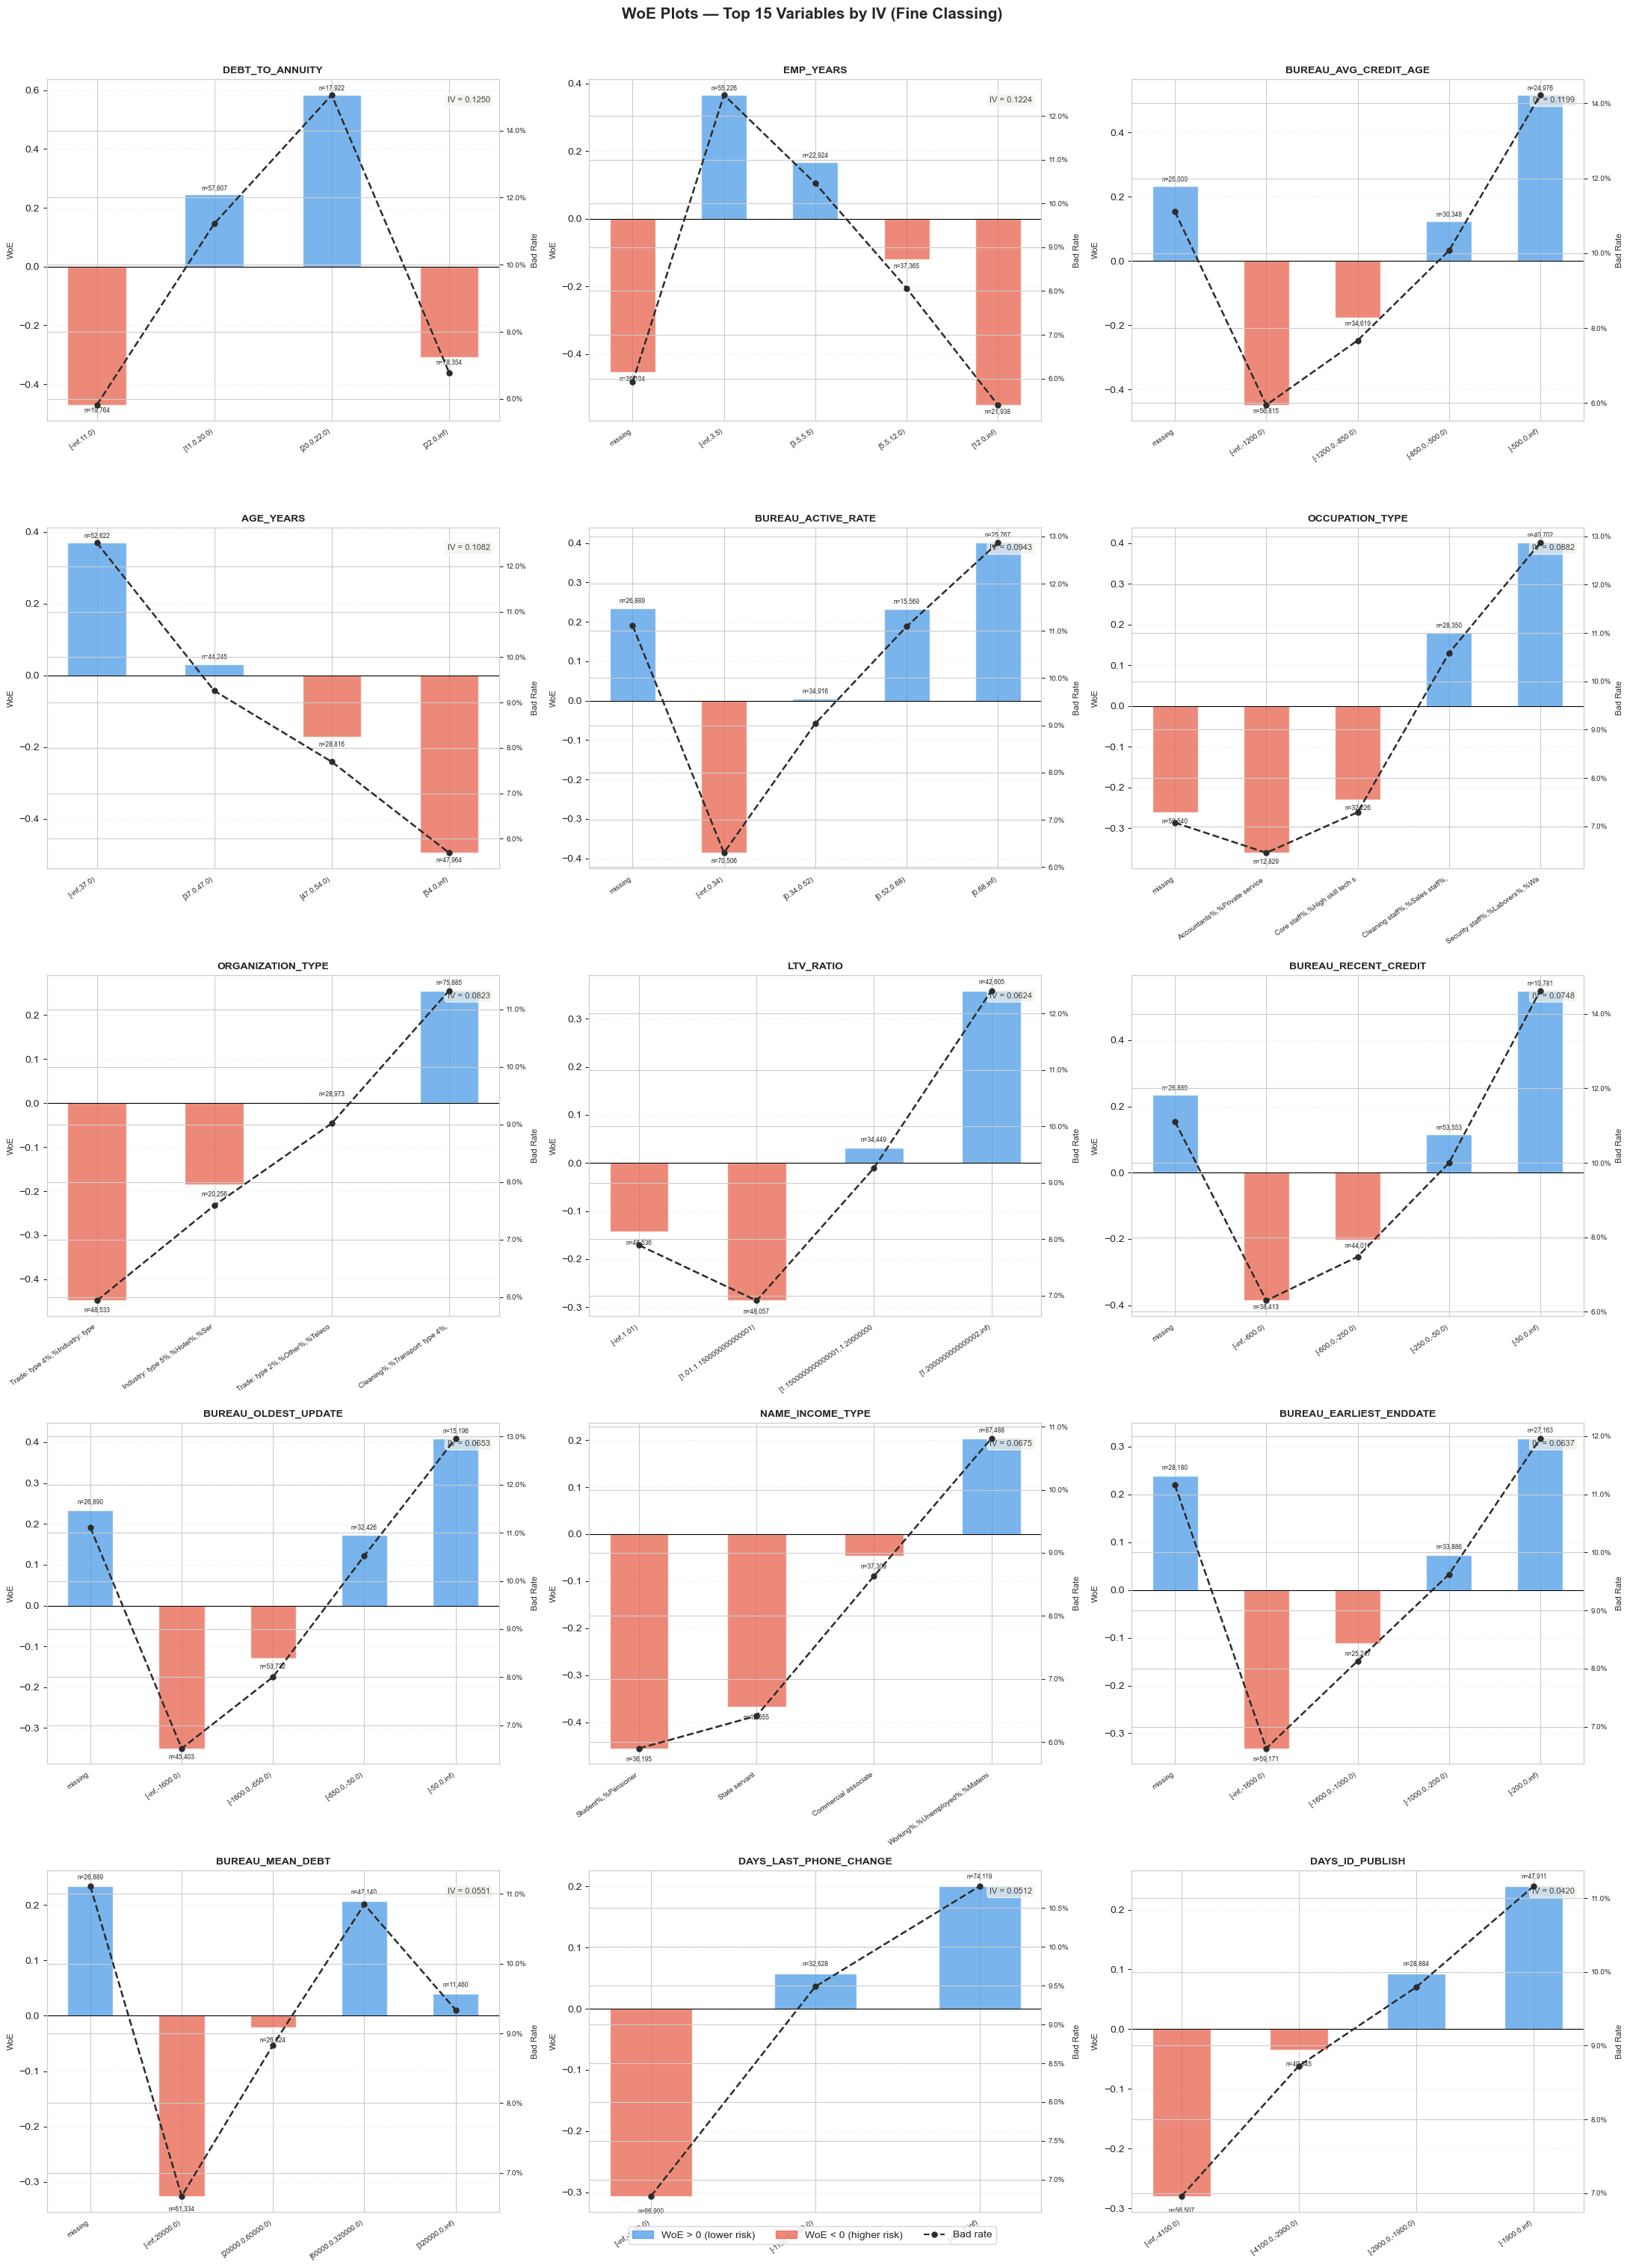

Saved: woe_plots_top15.png


In [ ]:
top15_vars = [
    'DEBT_TO_ANNUITY', 'EMP_YEARS', 'BUREAU_AVG_CREDIT_AGE', 'AGE_YEARS',
    'BUREAU_ACTIVE_RATE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'LTV_RATIO',
    'BUREAU_RECENT_CREDIT', 'BUREAU_OLDEST_UPDATE', 'NAME_INCOME_TYPE',
    'BUREAU_EARLIEST_ENDDATE', 'BUREAU_MEAN_DEBT', 'DAYS_LAST_PHONE_CHANGE',
    'DAYS_ID_PUBLISH'
]

# Filter to variables that exist in bins_fine
vars_to_plot = [v for v in top15_vars if v in bins]
print(f"Plotting {len(vars_to_plot)} variables")

fig, axes = plt.subplots(5, 3, figsize=(22, 30))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    ax = axes[i]
    bin_df = bins[var].copy()
    
    # Drop total_iv summary row if present
    if 'total_iv' in bin_df.columns:
        bin_df = bin_df[bin_df['bin'] != 'total_iv'].copy()
    
    # Shorten long bin labels for readability
    bin_df['bin_label'] = bin_df['bin'].astype(str).str[:30]
    
    x = np.arange(len(bin_df))
    woe_vals = bin_df['woe'].values
    bad_prob  = bin_df['badprob'].values if 'badprob' in bin_df.columns else None
    
    # ── Bar: WoE values ──
    colors = ['#E8624C' if w < 0 else '#4C9BE8' for w in woe_vals]
    bars = ax.bar(x, woe_vals, color=colors, alpha=0.75, width=0.5, zorder=2)
    
    # ── Line: Bad rate (secondary axis) ──
    if bad_prob is not None:
        ax2 = ax.twinx()
        ax2.plot(x, bad_prob, color='#2C2C2A', marker='o', markersize=5,
                 linewidth=1.8, linestyle='--', label='Bad rate', zorder=3)
        ax2.set_ylabel('Bad Rate', fontsize=8, color='#2C2C2A')
        ax2.tick_params(axis='y', labelsize=7)
        ax2.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f'{v*100:.1f}%')
        )
    
    # ── Formatting ──
    ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
    ax.set_xticks(x)
    ax.set_xticklabels(bin_df['bin_label'], rotation=35, ha='right', fontsize=7)
    ax.set_ylabel('WoE', fontsize=8)
    ax.set_title(f'{var}', fontsize=10, fontweight='bold')
    ax.grid(axis='y', linestyle=':', alpha=0.4, zorder=1)
    
    # ── IV annotation ──
    iv_val = bins[var]['total_iv'].iloc[0] \
             if 'total_iv' in bins[var].columns else 0
    ax.annotate(f'IV = {iv_val:.4f}', xy=(0.98, 0.95),
                xycoords='axes fraction', ha='right', va='top',
                fontsize=8, color='#444',
                bbox=dict(boxstyle='round,pad=0.3', fc='#F1EFE8', alpha=0.7))
    
    # ── Count labels on bars ──
    if 'count' in bin_df.columns:
        for bar, cnt in zip(bars, bin_df['count'].values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01 if bar.get_height() >= 0 
                    else bar.get_height() - 0.03,
                    f'n={int(cnt):,}', ha='center', va='bottom', fontsize=6)

# Hide unused subplots
for j in range(len(vars_to_plot), len(axes)):
    axes[j].set_visible(False)

# ── Legend ──
pos_patch = mpatches.Patch(color='#4C9BE8', alpha=0.75, label='WoE > 0 (lower risk)')
neg_patch = mpatches.Patch(color='#E8624C', alpha=0.75, label='WoE < 0 (higher risk)')
bad_line  = plt.Line2D([0], [0], color='#2C2C2A', linestyle='--',
                        marker='o', markersize=5, label='Bad rate')
fig.legend(handles=[pos_patch, neg_patch, bad_line],
           loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, 0.01))

plt.suptitle('WoE Plots — Top 15 Variables by IV (Fine Classing)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
##investigate non-monotone variables

for var in ['DEBT_TO_ANNUITY', 'LTV_RATIO', 'BUREAU_MEAN_DEBT']:
    print(f"\n{'='*60}")
    print(f"Variable: {var}")
    print(f"{'='*60}")
    bin_df = bins[var].copy()
    display_cols = ['bin', 'count', 'count_distr', 'good', 'bad', 'badprob', 'woe', 'iv']
    available_cols = [c for c in display_cols if c in bin_df.columns]
    print(bin_df[available_cols].to_string(index=False))


Variable: DEBT_TO_ANNUITY
        bin  count  count_distr  good  bad  badprob   woe
[-inf,11.0)  19764         0.11 18614 1150     0.06 -0.47
[11.0,20.0)  57607         0.33 51141 6466     0.11  0.25
[20.0,22.0)  17922         0.10 15223 2699     0.15  0.58
 [22.0,inf)  78354         0.45 73040 5314     0.07 -0.31

Variable: LTV_RATIO
                                    bin  count  count_distr  good  bad  badprob   woe
                            [-inf,1.01)  48536         0.28 44705 3831     0.08 -0.14
              [1.01,1.1500000000000001)  48057         0.28 44735 3322     0.07 -0.29
[1.1500000000000001,1.2000000000000002)  34449         0.20 31258 3191     0.09  0.03
               [1.2000000000000002,inf)  42605         0.25 37320 5285     0.12  0.36

Variable: BUREAU_MEAN_DEBT
               bin  count  count_distr  good  bad  badprob   woe
           missing  26889         0.15 23901 2988     0.11  0.23
    [-inf,20000.0)  61334         0.35 57247 4087     0.07 -0.33
 [20000.0

In [ ]:
# Here's my analysis of each variable and the exact fixes:

# ---

# **DEBT_TO_ANNUITY — U-shaped pattern**
# WoE goes: -0.47 → +0.25 → +0.58 → -0.31. The last bin [22, inf) drops back down, breaking monotonicity. The middle two bins (11–22) are the sweet spot for risk. Fix by merging the two extreme bins:

# ```python
# # Merge [22, inf) with [11, 20) to force monotonic increase
# breaks_adj['DEBT_TO_ANNUITY'] = [11.0, 22.0]
# # Result: <11 (low risk), 11-22 (medium), >22 (merge back to lower risk)
# # OR just use 2 bins — below/above 20 where the peak risk sits
# breaks_adj['DEBT_TO_ANNUITY'] = [20.0]
# ```

# ---

# **LTV_RATIO — dip in the middle**
# WoE goes: -0.14 → -0.29 → +0.03 → +0.36. The second bin dips lower than the first, breaking monotonicity. Fix by merging the first two bins:

# ```python
# # Merge [-inf, 1.01) and [1.01, 1.15) into one bin
# breaks_adj['LTV_RATIO'] = [1.15, 1.20]
# # Result: <1.15 (low risk), 1.15-1.20 (medium), >1.20 (high risk) — clean monotonic increase
# ```

# ---

# **BUREAU_MEAN_DEBT — missing bin + non-monotonic middle**
# WoE goes: missing=+0.23 → -0.33 → -0.02 → +0.21 → +0.04. Two issues:
# 1. The missing bin (+0.23) sits at the top but breaks the sequence
# 2. The last bin [320k, inf) drops back from +0.21 to +0.04

# Fix by merging middle bins and the last two bins:

# ```python
# # Merge the flat middle bins and collapse the tail
# breaks_adj['BUREAU_MEAN_DEBT'] = [0, 60000.0]
# # Result: missing | <0 | 0-60k (low risk) | >60k (high risk)
# # The missing bin gets its own WoE naturally
# ```

# ---

# **All three fixes together:**

# ```python
# breaks_adj = {
#     'DEBT_TO_ANNUITY'  : [20.0],
#     'LTV_RATIO'        : [1.15, 1.20],
#     'BUREAU_MEAN_DEBT' : [0, 60000.0],
# }

# # Re-run coarse classing with these breaks
# bins_coarse = sc.woebin(
#     df_train,
#     y='TARGET',
#     breaks_list=breaks_adj,
#     positive='bad|1',
#     print_step=0
# )

# # Verify monotonicity
# for var in ['DEBT_TO_ANNUITY', 'LTV_RATIO', 'BUREAU_MEAN_DEBT']:
#     print(f"\n{var}")
#     bin_df = bins_coarse[var]
#     display_cols = ['bin', 'count', 'badprob', 'woe']
#     print(bin_df[[c for c in display_cols if c in bin_df.columns]].to_string(index=False))
# ```

# Paste the output and I'll confirm whether the monotonicity is resolved or needs further adjustment.